In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from mad.configs import EARTH_SETTINGS, tomahawk, tomahawk_guidance
from mad.objs import Planet, PlanetConfig
from mad.objs import CruiseMissile, CruiseMissileConfig
from mad.guidances import CruiseWaypointGuidance, CruiseGuidanceConfig
from mad.simulation import Simulation
from mad.utils.logger import SourceLogger
from mad.utils.plotters import plot_2D_planet_with_points

logger = SourceLogger()

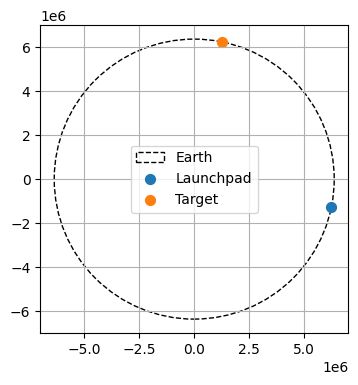

In [3]:
EARTH_SETTINGS["position"] = [0.0, 0.0]

launchsite_target_distance_km = 10_000
earth = Planet(PlanetConfig(**EARTH_SETTINGS))
launchpad = earth.random_point_at_surface(name="Launchpad", altitude=10)
target = earth.point_at_distance(launchpad, distance_km=launchsite_target_distance_km, name="Target")
waypoints = [launchpad, target]
plot_2D_planet_with_points(earth, points = waypoints, display="planet");

In [4]:
tomahawk

{'name': 'Tomahawk',
 'mass': 1300.0,
 'ref_radius': 0.25,
 'Cd': 0.5,
 'thrust_acc': 30.0}

In [5]:
# thrust_acc is already 30 m/s² in the default config; keep realistic mass


In [25]:
guidance_config = CruiseGuidanceConfig(**tomahawk_guidance, waypoints=waypoints)
guidance = CruiseWaypointGuidance(planet = earth, config=guidance_config, target=target)

tomahawk_missile = CruiseMissile(position=launchpad.position.copy(), config=CruiseMissileConfig(**tomahawk, guidance=guidance))
    

13:53:07 | INFO     | Guidance     | CruiseWaypointGuidance: spline built over 2 waypoints (52 dense points), total arc length 9999.7 km.


In [26]:
dt = 1.0
max_time = 50_000.0  # enough for 10 000 km at ~250 m/s

sim = Simulation(max_time=max_time, dt=dt)
sim.run(
    planet=earth,
    moving_objs=[tomahawk_missile],
)

df = sim.results


13:53:10 | INFO     | Simulation   | Starting simulation.
13:53:33 | INFO     | Simulation   | Simulation ended at 50000.00s. Took 22.88 s of real time.


In [24]:
import importlib, mad.guidances.cruise_missiles_guidances as cmg
importlib.reload(cmg)
from mad.guidances.cruise_missiles_guidances import CruiseWaypointGuidance, CruiseGuidanceConfig
import numpy as np

# Manual step-by-step to trace what happens
guidance3 = CruiseWaypointGuidance(planet=earth, config=guidance_config, target=target)
missile3 = CruiseMissile(position=launchpad.position.copy(), config=CruiseMissileConfig(**tomahawk, guidance=guidance3))

print(f"Initial alt: {np.linalg.norm(missile3.position) - earth.radius:.2f} m")
print(f"Initial vel: {missile3.velocity}")

for i in range(15):
    alt = np.linalg.norm(missile3.position) - earth.radius
    res = missile3.guidance_results
    if res is not None:
        r_hat = missile3.position / np.linalg.norm(missile3.position)
        # Compute actual thrust applied
        d = res.direction
        d_norm = np.linalg.norm(d)
        if d_norm > 1e-8:
            desired = res.magnitude
            acc = min(tomahawk["thrust_acc"], desired) if desired is not None else tomahawk["thrust_acc"]
            thrust_vec = acc * (d / d_norm)
            radial_thrust = float(np.dot(thrust_vec, r_hat))
        else:
            radial_thrust = 0.0
        g = earth.mu / np.linalg.norm(missile3.position)**2
        print(f"t={i:2d}s alt={alt:.2f}m radial_thrust={radial_thrust:.3f} g={g:.3f} net_up={radial_thrust-g:.3f} mag={res.magnitude}")
    missile3.update(1.0)
    missile3.integrate(1.0, earth)
    if not missile3.active:
        print(f"CRASHED at t={i+1}")
        break


13:52:52 | INFO     | Guidance     | CruiseWaypointGuidance: spline built over 2 waypoints (52 dense points), total arc length 9999.7 km.
Initial alt: 10.00 m
Initial vel: [0. 0. 0.]
t= 0s alt=10.00m radial_thrust=13.553 g=9.820 net_up=3.734 mag=None
t= 1s alt=11.87m radial_thrust=13.553 g=9.820 net_up=3.734 mag=None
t= 2s alt=16.98m radial_thrust=12.573 g=9.820 net_up=2.754 mag=None
t= 3s alt=24.27m radial_thrust=11.468 g=9.820 net_up=1.648 mag=None
t= 4s alt=32.65m radial_thrust=10.365 g=9.820 net_up=0.545 mag=None
t= 5s alt=41.04m radial_thrust=9.389 g=9.820 net_up=-0.431 mag=None
t= 6s alt=48.59m radial_thrust=8.638 g=9.819 net_up=-1.182 mag=None
t= 7s alt=54.66m radial_thrust=8.164 g=9.819 net_up=-1.656 mag=None
t= 8s alt=58.94m radial_thrust=7.969 g=9.819 net_up=-1.851 mag=None
t= 9s alt=61.36m radial_thrust=8.017 g=9.819 net_up=-1.802 mag=None
t=10s alt=62.08m radial_thrust=8.247 g=9.819 net_up=-1.572 mag=None
t=11s alt=62.01m radial_thrust=9.819 g=9.819 net_up=-0.000 mag=9.8194

In [27]:
df["altitude_km"] = df["position"].apply(lambda pos: (np.linalg.norm(pos) - earth.radius) / 1e3)
df["energy_kJ"] = df["speed"].apply(lambda speed: 0.5 * speed**2 / 1e3)
df["gamma_deg"] = df["gamma"].apply(lambda g: np.degrees(g) if g is not None else None)
df = df.sort_values(by=["name", "time"])

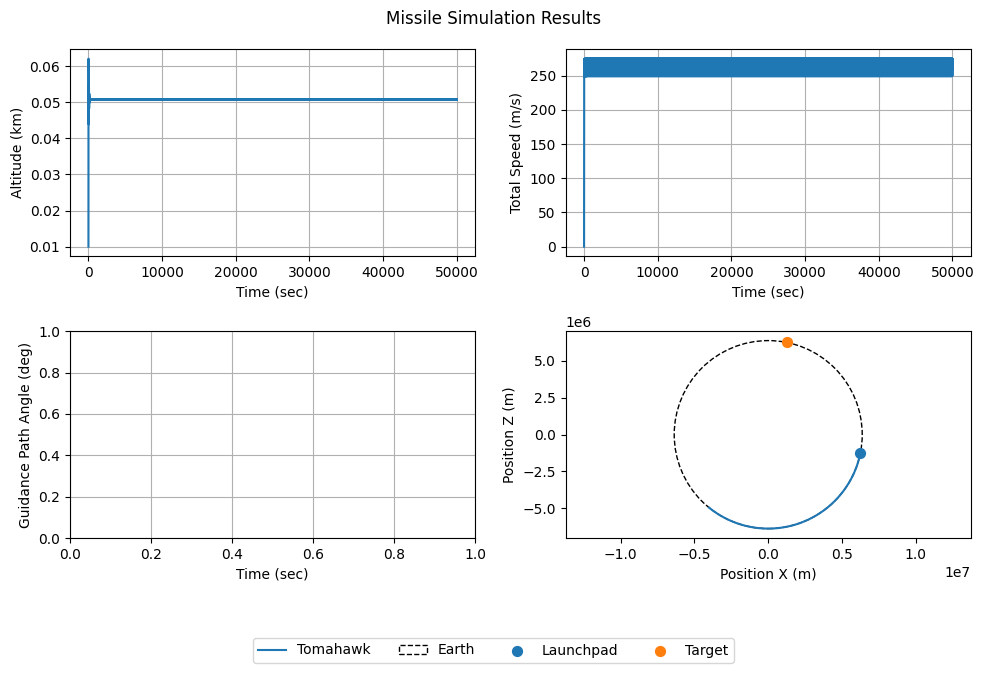

In [28]:
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(10, 6))
ax = ax.ravel()

sns.lineplot(data=df, x="time", y="altitude_km", hue="name", ax=ax[0])
sns.lineplot(data=df, x="time", y="speed", hue="name", ax=ax[1])
sns.lineplot(data=df, x="time", y="gamma_deg", hue="name", ax=ax[2])
sns.lineplot(data=df, x="posx", y="posz", hue="name", ax=ax[3], sort=False, errorbar=None)

ax[0].set_xlabel("Time (sec)")
ax[0].set_ylabel("Altitude (km)")

ax[1].set_xlabel("Time (sec)")
ax[1].set_ylabel("Total Speed (m/s)")

ax[2].set_xlabel("Time (sec)")
ax[2].set_ylabel("Guidance Path Angle (deg)")

plot_2D_planet_with_points(earth, points = [launchpad, target], ax=ax[3], display="planet")
ax[3].set_xlabel("Position X (m)")
ax[3].set_ylabel("Position Z (m)")
ax[3].set_aspect("equal", adjustable="datalim")

for a in ax:
    a.grid()
    a.legend()
    handles, labels = a.get_legend_handles_labels()
    a.legend().remove()

fig.suptitle("Missile Simulation Results")
fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.12))
fig.tight_layout(pad=1.2)